In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score
from sklearn.linear_model import LinearRegression
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Data/powerset.csv")
df1=df

In [3]:
df.head()

,Community_ID,SolarEnergy_aspect1,SolarEnergy_aspect2,SolarEnergy_aspect3,SolarEnergy_aspect4,SolarEnergy_aspect5,Behavioural_aspect1,Behavioural_aspect2,Behavioural_aspect3,Behavioural_aspect4,Behavioural_aspect5,Power_Consumption
0,CC123888,NoSolarPowerEquipped,AddnlSolarPower,MinPowerNotEnabled,BatteriesEquipped,DCtoACEquipped,Awareness,ACsOnNeed,NoSlabs,Auto-Off,StreetLightsNotEquipped,Controlled
1,CC176566,NoSolarPowerEquipped,AddnlSolarPower,MinPowerNotEnabled,BatteriesEquipped,DCtoACnotEquipped,Awareness,ACsAllTime,Slabs,NoAuto-Off,StreetLightsEquipped,Controlled
2,CC198149,NoSolarPowerEquipped,NoAddnlPower,MinPowerEnabled,BatteriesNotEquipped,DCtoACEquipped,Awareness,ACsOnNeed,NoSlabs,NoAuto-Off,StreetLightsEquipped,Controlled
3,CC189824,SolarPowerEquipped,AddnlSolarPower,MinPowerEnabled,BatteriesNotEquipped,DCtoACEquipped,NoAwareness,ACsOnNeed,NoSlabs,Auto-Off,StreetLightsNotEquipped,Controlled
4,CC197679,NoSolarPowerEquipped,AddnlSolarPower,MinPowerEnabled,BatteriesNotEquipped,DCtoACEquipped,Awareness,ACsAllTime,Slabs,Auto-Off,StreetLightsNotEquipped,Controlled


In [4]:
df.tail()

,Community_ID,SolarEnergy_aspect1,SolarEnergy_aspect2,SolarEnergy_aspect3,SolarEnergy_aspect4,SolarEnergy_aspect5,Behavioural_aspect1,Behavioural_aspect2,Behavioural_aspect3,Behavioural_aspect4,Behavioural_aspect5,Power_Consumption
2091,CC136091,SolarPowerEquipped,AddnlSolarPower,MinPowerNotEnabled,BatteriesNotEquipped,DCtoACnotEquipped,Awareness,ACsAllTime,Slabs,NoAuto-Off,StreetLightsNotEquipped,Uncontrolled
2092,CC212020,SolarPowerEquipped,AddnlSolarPower,MinPowerEnabled,BatteriesEquipped,DCtoACnotEquipped,Awareness,ACsOnNeed,NoSlabs,Auto-Off,StreetLightsNotEquipped,Controlled
2093,CC183900,NoSolarPowerEquipped,AddnlSolarPower,MinPowerEnabled,BatteriesNotEquipped,DCtoACnotEquipped,NoAwareness,ACsAllTime,Slabs,NoAuto-Off,StreetLightsEquipped,Uncontrolled
2094,CC213972,SolarPowerEquipped,AddnlSolarPower,MinPowerEnabled,BatteriesEquipped,DCtoACnotEquipped,NoAwareness,ACsAllTime,Slabs,Auto-Off,StreetLightsNotEquipped,Controlled
2095,CC201071,NoSolarPowerEquipped,AddnlSolarPower,MinPowerEnabled,BatteriesNotEquipped,DCtoACnotEquipped,Awareness,ACsAllTime,Slabs,NoAuto-Off,StreetLightsEquipped,Controlled


In [5]:
df.isnull().sum()

Community_ID           0
SolarEnergy_aspect1    0
SolarEnergy_aspect2    0
SolarEnergy_aspect3    0
SolarEnergy_aspect4    0
SolarEnergy_aspect5    0
Behavioural_aspect1    0
Behavioural_aspect2    0
Behavioural_aspect3    0
Behavioural_aspect4    0
Behavioural_aspect5    0
Power_Consumption      0
dtype: int64

In [6]:
df.shape

(2096, 12)

In [7]:
df.columns

Index(['Community_ID', 'SolarEnergy_aspect1', 'SolarEnergy_aspect2',
       'SolarEnergy_aspect3', 'SolarEnergy_aspect4', 'SolarEnergy_aspect5',
       'Behavioural_aspect1', 'Behavioural_aspect2', 'Behavioural_aspect3',
       'Behavioural_aspect4', 'Behavioural_aspect5', 'Power_Consumption'],
      dtype='object')

In [8]:
df=df.drop(columns='Community_ID')

In [9]:
print(df['SolarEnergy_aspect1'].unique())
print(df['SolarEnergy_aspect2'].unique())
print(df['SolarEnergy_aspect3'].unique())
print(df['SolarEnergy_aspect4'].unique())
print(df['SolarEnergy_aspect5'].unique())

['NoSolarPowerEquipped' 'SolarPowerEquipped']
['AddnlSolarPower' 'NoAddnlPower']
['MinPowerNotEnabled' 'MinPowerEnabled']
['BatteriesEquipped' 'BatteriesNotEquipped']
['DCtoACEquipped' 'DCtoACnotEquipped']


In [10]:
print(df['Behavioural_aspect1'].unique())
print(df['Behavioural_aspect2'].unique())
print(df['Behavioural_aspect3'].unique())
print(df['Behavioural_aspect4'].unique())
print(df['Behavioural_aspect5'].unique())

['Awareness' 'NoAwareness']
['ACsOnNeed' 'ACsAllTime']
['NoSlabs' 'Slabs']
['Auto-Off' 'NoAuto-Off']
['StreetLightsNotEquipped' 'StreetLightsEquipped']


In [11]:
print(df['Power_Consumption'].value_counts())

Power_Consumption
Uncontrolled    1073
Controlled      1023
Name: count, dtype: int64


In [12]:
cols=df.columns

In [13]:
for i in cols:
    df[i]=df[i].fillna(df[i].mode()[0])

In [14]:
df.isnull().sum()

SolarEnergy_aspect1    0
SolarEnergy_aspect2    0
SolarEnergy_aspect3    0
SolarEnergy_aspect4    0
SolarEnergy_aspect5    0
Behavioural_aspect1    0
Behavioural_aspect2    0
Behavioural_aspect3    0
Behavioural_aspect4    0
Behavioural_aspect5    0
Power_Consumption      0
dtype: int64

In [15]:
cols1=df.drop(columns=['Power_Consumption'])
df=pd.get_dummies(df,columns=cols1.columns,drop_first=True)

In [16]:
le=LabelEncoder()
df['Power_Consumption']=le.fit_transform(df['Power_Consumption'])

In [17]:
df.head(20)

,Power_Consumption,SolarEnergy_aspect1_SolarPowerEquipped,SolarEnergy_aspect2_NoAddnlPower,SolarEnergy_aspect3_MinPowerNotEnabled,SolarEnergy_aspect4_BatteriesNotEquipped,SolarEnergy_aspect5_DCtoACnotEquipped,Behavioural_aspect1_NoAwareness,Behavioural_aspect2_ACsOnNeed,Behavioural_aspect3_Slabs,Behavioural_aspect4_NoAuto-Off,Behavioural_aspect5_StreetLightsNotEquipped
0,0,False,False,True,False,False,False,True,False,False,True
1,0,False,False,True,False,True,False,False,True,True,False
2,0,False,True,False,True,False,False,True,False,True,False
3,0,True,False,False,True,False,True,True,False,False,True
4,0,False,False,False,True,False,False,False,True,False,True
5,0,True,False,True,False,True,False,True,True,False,True
6,1,True,True,True,True,True,True,False,False,True,True
7,0,True,False,False,True,False,True,False,True,False,False
8,1,False,True,False,True,True,False,False,False,True,False
9,1,False,True,False,True,False,True,True,False,True,False


In [18]:
df.shape

(2096, 11)

In [19]:
df.columns

Index(['Power_Consumption', 'SolarEnergy_aspect1_SolarPowerEquipped',
       'SolarEnergy_aspect2_NoAddnlPower',
       'SolarEnergy_aspect3_MinPowerNotEnabled',
       'SolarEnergy_aspect4_BatteriesNotEquipped',
       'SolarEnergy_aspect5_DCtoACnotEquipped',
       'Behavioural_aspect1_NoAwareness', 'Behavioural_aspect2_ACsOnNeed',
       'Behavioural_aspect3_Slabs', 'Behavioural_aspect4_NoAuto-Off',
       'Behavioural_aspect5_StreetLightsNotEquipped'],
      dtype='object')

In [37]:
x=df.drop(columns='Power_Consumption')
y=df['Power_Consumption']

In [38]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=5,stratify=y)

In [39]:
print(Y_train.value_counts())
print(Y_test.value_counts())

Power_Consumption
1    858
0    818
Name: count, dtype: int64
Power_Consumption
1    215
0    205
Name: count, dtype: int64


In [40]:
model=LinearRegression()
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
pred=model.predict(X_test)

In [42]:
print("MSE:-",mean_squared_error(Y_test,pred))
print("MAE:-",mean_absolute_error(Y_test,pred))
print("RMSE:-",np.sqrt(mean_squared_error(Y_test,pred)))
print("R2_score:-",r2_score(Y_test,pred))

MSE:- 0.071589827828398
MAE:- 0.2196668481676327
RMSE:- 0.26756275493498344
R2_score:- 0.7134782613969505


In [43]:
grid={
    "fit_intercept":[True,False],
    "positive":[True,False],
    "copy_X":[True,False]
}
grid_cv=GridSearchCV(
    model,
    grid,
    cv=5,
    scoring='r2'
)

In [44]:
grid_cv.fit(X_train,Y_train)

,estimator,LinearRegression()
,param_grid,"{'copy_X': [True, False], 'fit_intercept': [True, False], 'positive': [True, False]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,fit_intercept,False


In [45]:
print(grid_cv.best_params_)
print(grid_cv.best_estimator_)

{'copy_X': True, 'fit_intercept': False, 'positive': False}
LinearRegression(fit_intercept=False)


In [46]:
y_pred=grid_cv.predict(X_test)

In [47]:
print(round(r2_score(Y_test,y_pred)*100,2))

71.27


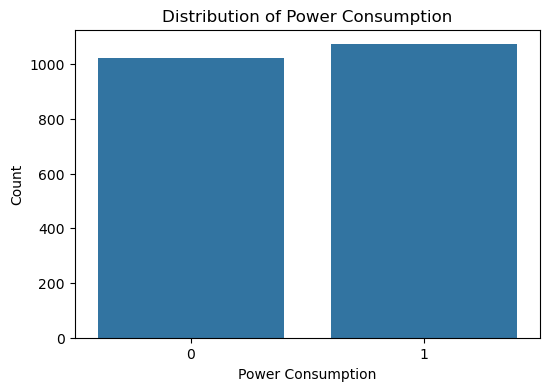

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(x="Power_Consumption", data=df)

plt.title("Distribution of Power Consumption")
plt.xlabel("Power Consumption")
plt.ylabel("Count")

plt.show()

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe of features and coefficients
importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

# Take absolute value to measure importance
importance["Importance"] = abs(importance["Coefficient"])

# Sort features by importance
importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

                                       Feature  Coefficient  Importance
8               Behavioural_aspect4_NoAuto-Off     0.409751    0.409751
9  Behavioural_aspect5_StreetLightsNotEquipped     0.265348    0.265348
4        SolarEnergy_aspect5_DCtoACnotEquipped     0.178885    0.178885
6                Behavioural_aspect2_ACsOnNeed    -0.176658    0.176658
1             SolarEnergy_aspect2_NoAddnlPower     0.172798    0.172798
0       SolarEnergy_aspect1_SolarPowerEquipped    -0.169266    0.169266
5              Behavioural_aspect1_NoAwareness     0.153430    0.153430
7                    Behavioural_aspect3_Slabs    -0.151025    0.151025
3     SolarEnergy_aspect4_BatteriesNotEquipped     0.150209    0.150209
2       SolarEnergy_aspect3_MinPowerNotEnabled     0.132452    0.132452


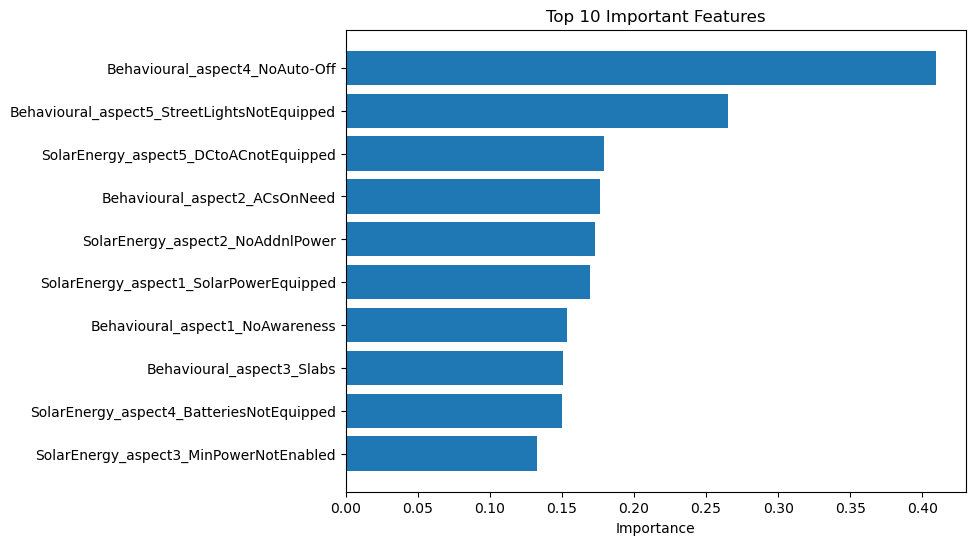

In [50]:
top_features = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

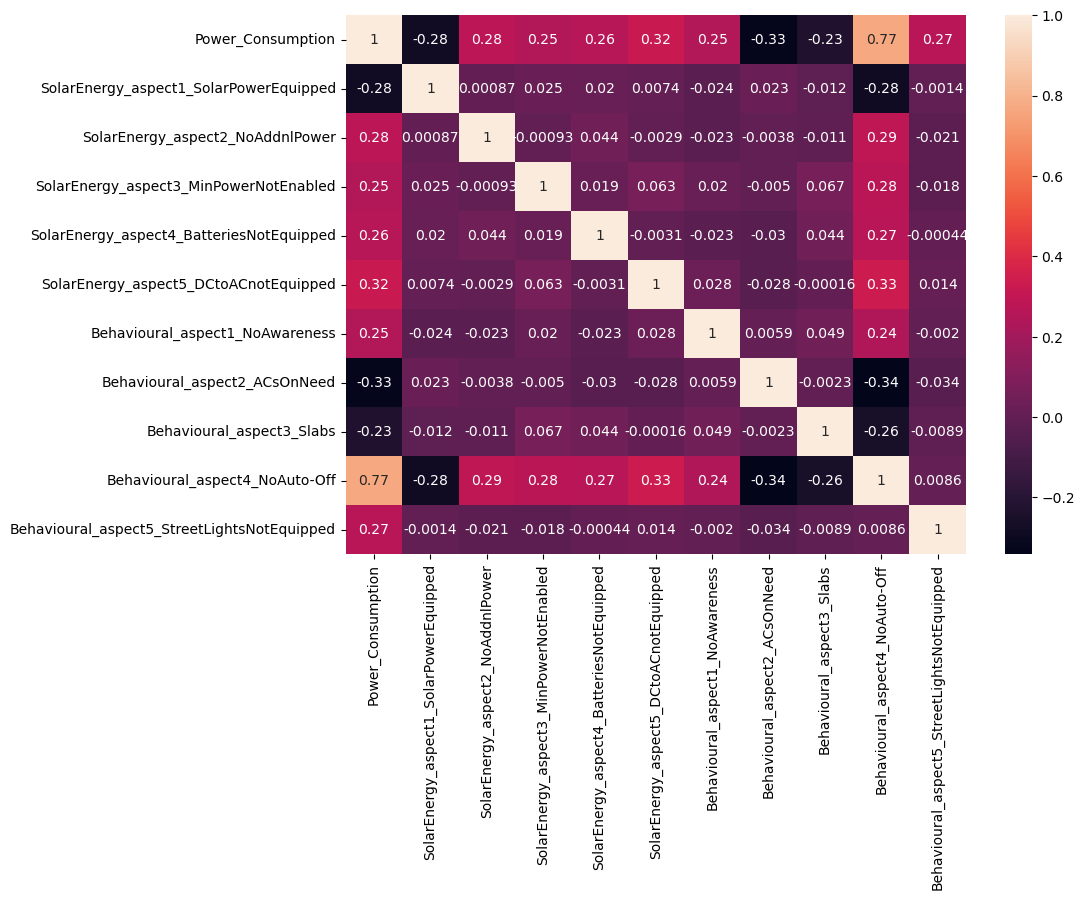

In [56]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [51]:
joblib.dump(model,"model/Linear_Regression_model.joblib")

['model/Linear_Regression_model.joblib']

In [52]:
print("Model Saved Successfully")

Model Saved Successfully
